# Lab 06 — Reinforcement learning

*Learn a policy by interacting, then save it*

**Goal.** Train a tabular Q-learning agent on a small grid, evaluate its greedy policy separately from the exploratory training, draw the policy and the values it learned, and save the Q-table as the model.

**Data.** none — the 4×4 GridWorld is defined in the notebook

**Reading.** Chapter 20 (Reinforcement Learning Basics)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab06/` — training curve, training returns, greedy policy, metrics; `models/gridworld_q_table.npy`

**How much is scaffolded?** Fully worked. There is no dataset: the agent creates its own experience by acting.

**Workflow**

1. Part A — Tabular Q-learning in a 4×4 GridWorld
2. Part B — The Q-table is the model: save it and read the policy
3. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab06/`.

In [1]:
import re
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

RESULTS = PROJECT_ROOT / "results" / "lab06"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — Tabular Q-learning in a 4×4 GridWorld

The world is a $4\times4$ grid. The agent starts top-left and must reach the goal bottom-right while avoiding a trap. Each move costs a little ($-0.04$), reaching the goal pays $+1$, and falling into the trap costs $-1$ and ends the episode. Walking into a wall leaves the agent where it is. That is the whole environment: a `step` function that takes a state and an action and returns the next state, the reward, and whether the episode is over.

In [2]:
rng = np.random.default_rng(42)

ROWS, COLS = 4, 4
START, GOAL, TRAP = (0, 0), (3, 3), (1, 3)
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]        # up, down, left, right
ACTION_NAMES = ["up", "down", "left", "right"]
ARROWS = {"up": (0, 1), "down": (0, -1), "left": (-1, 0), "right": (1, 0)}

def step(state, action):
    """Apply one action. Returns (next_state, reward, done)."""
    r, c = state
    dr, dc = ACTIONS[action]
    next_state = (min(max(r + dr, 0), ROWS - 1), min(max(c + dc, 0), COLS - 1))
    if next_state == GOAL:
        return next_state, 1.0, True
    if next_state == TRAP:
        return next_state, -1.0, True
    return next_state, -0.04, False

The Q-table has one number per (cell, action): the agent's current estimate of the long-run return from taking that action there. It starts at zero. Each step, the estimate is nudged toward what actually happened: the reward received plus the discounted value of the best move from the next cell. The nudge size is α; the discount γ says how much future reward is worth today. Early on the agent explores at random ($\varepsilon=1$); as ε decays it exploits what it has learned.

In [3]:
Q = np.zeros((ROWS, COLS, len(ACTIONS)))
alpha, gamma = 0.15, 0.95
epsilon, min_epsilon = 1.0, 0.05

def choose_action(state, explore=True):
    if explore and rng.random() < epsilon:
        return int(rng.integers(len(ACTIONS)))       # explore: random move
    return int(np.argmax(Q[state]))                  # exploit: best known move

training_returns = []
for episode in range(5000):
    state, episode_return = START, 0.0
    for _ in range(100):
        action = choose_action(state)
        next_state, reward, done = step(state, action)
        episode_return += reward
        target = reward if done else reward + gamma * np.max(Q[next_state])
        Q[state][action] += alpha * (target - Q[state][action])
        state = next_state
        if done:
            break
    training_returns.append(episode_return)
    epsilon = max(min_epsilon, epsilon * 0.9985)

The training curve is the return per episode, smoothed over 100 episodes. Early returns are negative because a random walker wanders into the trap or times out; as exploration decays the curve rises to the best achievable return.

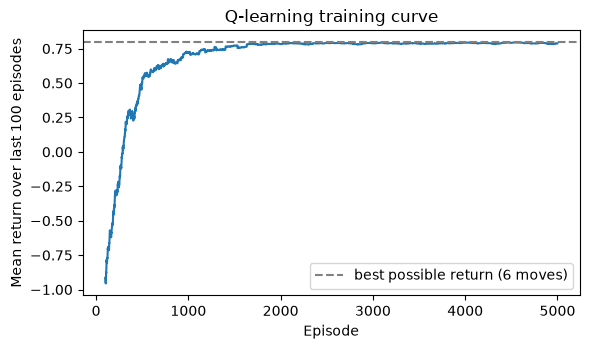

In [4]:
window = 100
moving = np.convolve(training_returns, np.ones(window) / window, mode="valid")
plt.figure(figsize=(6, 3.6))
plt.plot(np.arange(window - 1, len(training_returns)), moving)
plt.axhline(0.8, linestyle="--", color="grey", label="best possible return (6 moves)")
plt.xlabel("Episode")
plt.ylabel("Mean return over last 100 episodes")
plt.title("Q-learning training curve")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "q_learning_training_curve.png", dpi=160, bbox_inches="tight")
plt.show()

Training returns mix learning with random moves, so they are not a fair measure of the policy. Evaluation switches exploration off and follows the greedy policy: in each cell, take the action with the highest Q-value.

In [5]:
successes, returns = 0, []
for _ in range(200):
    state, total = START, 0.0
    for _ in range(100):
        state, reward, done = step(state, choose_action(state, explore=False))
        total += reward
        if done:
            successes += int(state == GOAL)
            break
    returns.append(total)

print("success rate:", successes / 200)
print("mean return:", round(float(np.mean(returns)), 3))
print("learned action at start:", ACTION_NAMES[choose_action(START, explore=False)])

success rate: 1.0
mean return: 0.8
learned action at start: down


**What to look for.** The shortest route is six moves: five at $-0.04$ and the sixth into the goal for $+1$, a return of $0.80$. A mean return of exactly $0.8$ with a 100% success rate means the agent found that route and never deviates from it.

**What the output shows.** The training curve climbs from negative returns (early wandering into the trap) to a plateau near 0.8. The greedy policy reaches the goal 200 times out of 200 with mean return 0.800, the best possible: five moves at −0.04 and a sixth into the goal for +1. There is no fixed dataset, no label, and no train/test split; the data depends on the policy being learned.

## Part B — The Q-table is the model: save it and read the policy

Everything the agent learned is in the Q-table, so saving it is saving the model. Anyone with the file can act without retraining: in each cell, pick the action with the largest value.

In [6]:
q_path = MODELS / "gridworld_q_table.npy"
np.save(q_path, Q)

Q_loaded = np.load(q_path)
policy = np.full((ROWS, COLS), "", dtype=object)
for r in range(ROWS):
    for c in range(COLS):
        policy[r, c] = "GOAL" if (r, c) == GOAL else "TRAP" if (r, c) == TRAP \
            else ACTION_NAMES[int(np.argmax(Q_loaded[r, c]))]
print(policy)

[['down' 'down' 'down' 'left']
 ['down' 'down' 'down' 'TRAP']
 ['right' 'down' 'down' 'down']
 ['right' 'right' 'right' 'GOAL']]


The policy is easier to read as arrows on the grid, drawn over a heat map of each cell's value (the best Q-value available there). Values rise towards the goal and drop next to the trap.

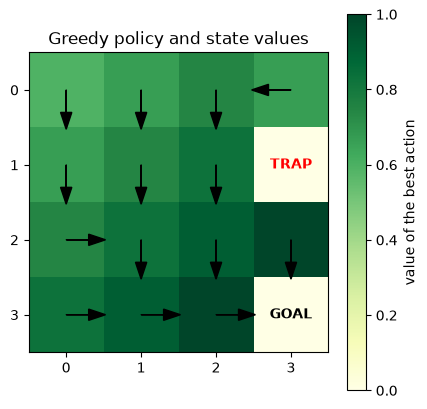

In [7]:
def plot_policy(Q_table, title):
    values = Q_table.max(axis=2)
    plt.figure(figsize=(4.4, 4.2))
    plt.imshow(values, cmap="YlGn")
    plt.colorbar(label="value of the best action")
    for r in range(ROWS):
        for c in range(COLS):
            if (r, c) == GOAL:
                plt.text(c, r, "GOAL", ha="center", va="center", fontweight="bold")
            elif (r, c) == TRAP:
                plt.text(c, r, "TRAP", ha="center", va="center", color="red", fontweight="bold")
            else:
                dx, dy = ARROWS[ACTION_NAMES[int(np.argmax(Q_table[r, c]))]]
                plt.arrow(c, r, 0.3 * dx, -0.3 * dy, head_width=0.15, color="black")
    plt.xticks(range(COLS))
    plt.yticks(range(ROWS))
    plt.title(title)
    plt.tight_layout()
    plt.savefig(RESULTS / (re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_") + ".png"), dpi=160, bbox_inches="tight")
    plt.show()

plot_policy(Q_loaded, "Greedy policy and state values")

**What to look for.** Every arrow points along a shortest path to the goal, and the arrows in the right-hand column steer away from the trap. The cell below the trap has a lower value than its neighbours because a random exploratory move from there was costly during training.

**What the output shows.** The arrows run down the left column, along the bottom row, and into the goal, steering clear of the trap at (1, 3); the value heat map rises towards the goal. A 640-byte file is enough to act without retraining.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [8]:
pd.DataFrame(policy, index=[f"row{r}" for r in range(ROWS)],
             columns=[f"col{c}" for c in range(COLS)]).to_csv(RESULTS / "greedy_policy.csv")
pd.DataFrame({"episode": np.arange(1, len(training_returns) + 1), "return": training_returns}).to_csv(
    RESULTS / "training_returns.csv", index=False)
pd.DataFrame([{"environment": "gridworld_4x4", "algorithm": "tabular_q_learning", "episodes": len(training_returns),
               "success_rate": successes / 200, "mean_greedy_return": float(np.mean(returns)),
               "start_action": ACTION_NAMES[choose_action(START, explore=False)]}]).round(4).to_csv(
    RESULTS / "metrics.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['greedy_policy.csv', 'greedy_policy_and_state_values.png', 'metrics.csv', 'q_learning_training_curve.png', 'training_returns.csv']


## Try it yourself

Change one thing: the step cost, the trap location, the exploration schedule, or the discount factor. Write down what you expect the greedy policy to do differently before retraining, then check with `plot_policy`.

Attempt it in the cell below before reading the solution.

In [9]:
# Your work here


### One solution

Move the trap onto the bottom row, at (3, 1). **Prediction before retraining:** the learned route runs down the left column and along the bottom row, straight through the new trap, so the arrows in the left column should stop pointing down and the route should shift to the top row and the right-hand column (or through the middle), for the same six-move length.

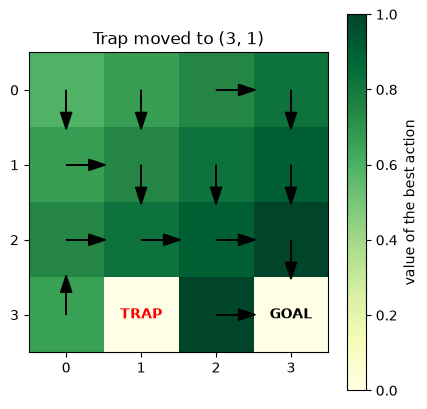

In [10]:
def train_q(trap, step_cost=-0.04, gamma_=0.95, episodes=5000, seed=42):
    """Retrain from scratch on a grid with the given trap position and step cost."""
    r = np.random.default_rng(seed)
    Q_new = np.zeros((ROWS, COLS, len(ACTIONS)))
    eps = 1.0

    def step_new(state, action):
        rr, cc = state
        dr, dc = ACTIONS[action]
        nxt = (min(max(rr + dr, 0), ROWS - 1), min(max(cc + dc, 0), COLS - 1))
        if nxt == GOAL:
            return nxt, 1.0, True
        if nxt == trap:
            return nxt, -1.0, True
        return nxt, step_cost, False

    for _ in range(episodes):
        state = START
        for _ in range(100):
            action = int(r.integers(len(ACTIONS))) if r.random() < eps else int(np.argmax(Q_new[state]))
            nxt, reward, done = step_new(state, action)
            target = reward if done else reward + gamma_ * np.max(Q_new[nxt])
            Q_new[state][action] += alpha * (target - Q_new[state][action])
            state = nxt
            if done:
                break
        eps = max(min_epsilon, eps * 0.9985)
    return Q_new

Q_moved = train_q(trap=(3, 1))
TRAP = (3, 1)                      # so plot_policy labels the new trap cell
plot_policy(Q_moved, "Trap moved to (3, 1)")
TRAP = (1, 3)                      # restore the lab's environment

**Check against the prediction.** The left-column arrows now turn right at row 2, one row above the trap, and the route runs across the middle of the grid and down into the goal; the cell directly beside the trap, (3, 0), points up, away from it. The right-hand column, which the original policy avoided, is now safe and its arrows point down. The path is still six moves, so the greedy return is still 0.8. The agent was never told the trap had moved; it relearned from the rewards alone, which is the whole point of learning by interaction rather than from a fixed dataset.